# GPA Prediction Engine

Dataset: https://drive.google.com/file/d/1xPEwYIIzh4J9TzwklXoWJ_lmNBU7QfC8/view?usp=sharing

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, f_oneway
from sklearn.cluster import KMeans
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

import shap

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)  # show all columns in output

c:\Users\leow0\OneDrive\Documents\Github\gpa-engine\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# load dataset -- each row is one student-semester record
df = pd.read_csv("my_data.csv")

print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Students: {df['id'].nunique()}")
print(f"Semesters per student: {df.groupby('id').size().median():.0f} (median)")

df.head()

Shape: 850000 rows, 14 columns
Students: 85000
Semesters per student: 10 (median)


,Unnamed: 0,id,lat,lon,gpa,avg_hours_studied,parents_income,major,tutoring,semester,year,credits,student_age,student_year
0,0,13251,38.878529,-76.776049,3.64,5,68628.72693,Math,No,Fall,2007,15,26,Freshman
1,1,13251,38.878529,-76.776049,3.65,5,68628.72693,Math,No,Spring,2008,15,27,Freshman
2,2,13251,38.878529,-76.776049,4.00,5,68628.72693,Math,No,Fall,2008,9,27,Sophmore
3,3,13251,38.878529,-76.776049,4.00,4,68628.72693,Math,No,Spring,2009,9,28,Sophmore
4,4,13251,38.878529,-76.776049,3.30,4,68628.72693,Math,No,Fall,2009,18,28,Junior


In [3]:
df.describe()

,Unnamed: 0,id,lat,lon,gpa,avg_hours_studied,parents_income,year,credits,student_age
count,850000.000000,850000.000000,850000.000000,850000.000000,850000.000000,850000.000000,850000.000000,850000.000000,850000.000000,850000.000000
mean,424999.500000,55750.500000,37.571625,-84.173308,3.557248,5.452056,88672.043587,2014.981153,13.497847,21.234847
std,245374.008743,24537.400873,2.772892,7.571554,0.607696,101.713719,30835.244514,4.858882,3.353551,2.509860
min,0.000000,13251.000000,32.048846,-94.722283,0.000000,0.000000,18229.301767,2005.000000,9.000000,17.000000
25%,212499.750000,34500.750000,38.390342,-93.388947,3.210000,3.000000,64654.681969,2011.000000,9.000000,20.000000
50%,424999.500000,55750.500000,39.050263,-77.554226,3.870000,4.000000,79958.265452,2015.000000,12.000000,21.000000
75%,637499.250000,77000.250000,39.295460,-76.813970,4.000000,5.000000,109606.323818,2019.000000,15.000000,22.000000
max,849999.000000,98250.000000,40.196585,-75.790679,4.100000,10000.000000,186445.742452,2025.000000,18.000000,33.000000


## 2. Exploratory Data Analysis

### GPA Distribution

The target variable is what we're trying to predict, so we need to understand its shape first. Is it normal? Skewed? Are there impossible values? This tells us if we need any transformations or outlier handling before modeling.

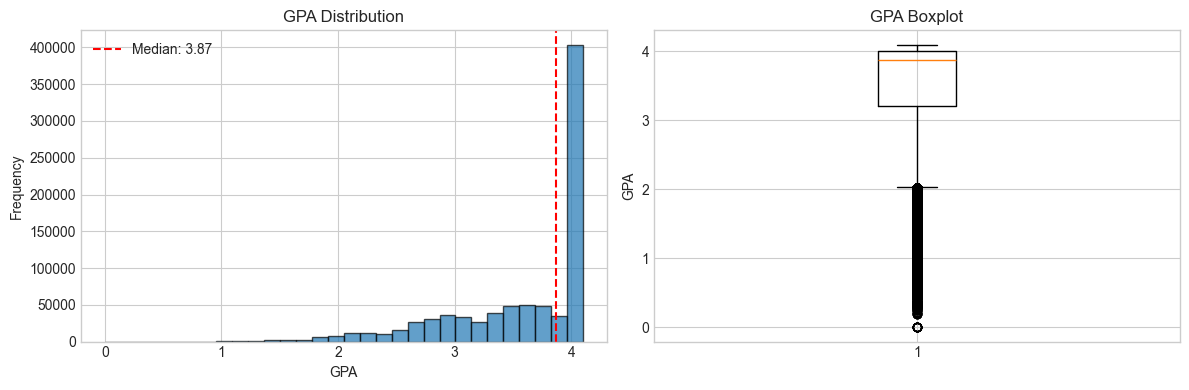

Range: [0.00, 4.10]
Values > 4.0: 75136 (will need capping)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# histogram -- shows frequency distribution of GPA values
axes[0].hist(df['gpa'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('GPA')
axes[0].set_ylabel('Frequency')
axes[0].set_title('GPA Distribution')

axes[0].axvline(
    df['gpa'].median(),
    color='red',
    linestyle='--',
    label=f"Median: {df['gpa'].median():.2f}"
)
axes[0].legend()

# boxplot -- highlights outliers beyond the whiskers
axes[1].boxplot(df['gpa'], vert=True)
axes[1].set_ylabel('GPA')
axes[1].set_title('GPA Boxplot')

plt.tight_layout()
plt.show()

print(f"Range: [{df['gpa'].min():.2f}, {df['gpa'].max():.2f}]")
print(f"Values > 4.0: {(df['gpa'] > 4.0).sum()} (will need capping)")

Heavy negative skew with a median of 3.87 and a massive ceiling effect at 4.0. There are 75,136 values that exceed 4.0, which shouldn't be possible, so those will need capping. The extreme concentration of high values means standard linear regression would struggle here. Tree-based models handle this better since they split on thresholds rather than assuming normality.

### Correlation Heatmap

A correlation heatmap computes the Pearson correlation coefficient between every pair of numeric features. Values range from -1 (perfect negative relationship) to +1 (perfect positive). This helps with two things: identifying which features have the strongest linear relationship with GPA, and spotting multicollinearity (when two features are highly correlated with each other, including both can confuse the model).

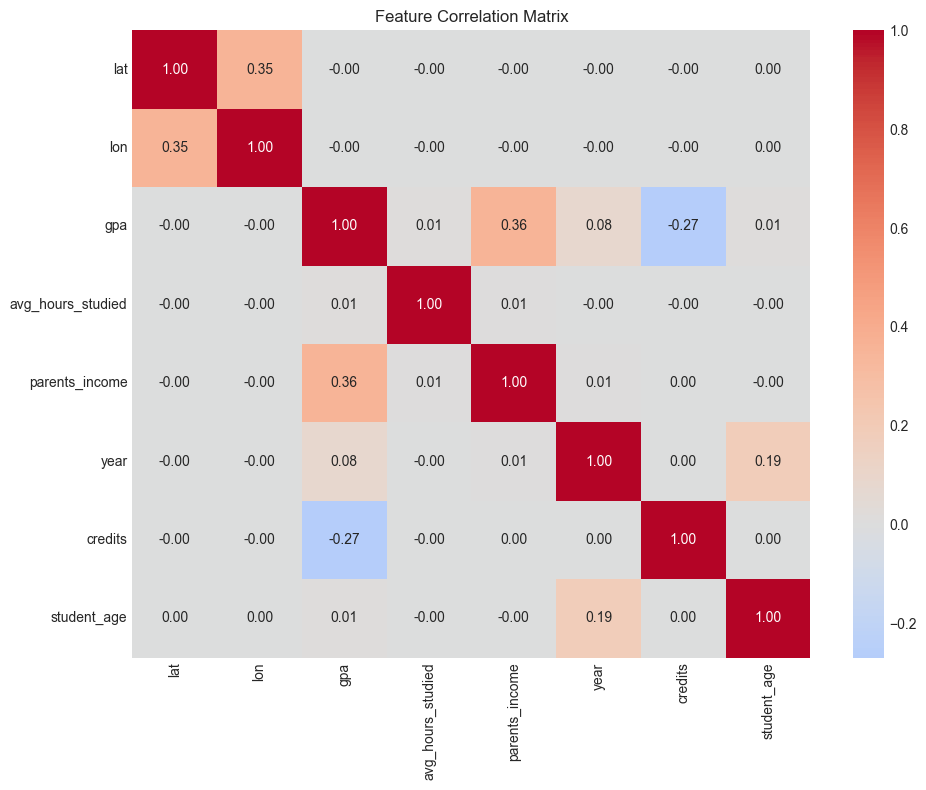

Top correlations with GPA:
parents_income       0.357558
credits             -0.268947
year                 0.084924
student_age          0.014539
avg_hours_studied    0.009344
Name: gpa, dtype: float64


In [5]:
# drop non-feature columns, compute pairwise correlations
numericCols = (
    df.select_dtypes(include=[np.number])
      .columns
      .drop(['Unnamed: 0', 'id'], errors='ignore')
)

corrMatrix = df[numericCols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corrMatrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# rank features by absolute correlation with GPA
gpaCorr = (
    corrMatrix['gpa']
    .drop('gpa')
    .sort_values(key=abs, ascending=False)
)

print("Top correlations with GPA:")
print(gpaCorr.head(5))

Parents' income has the strongest linear correlation with GPA (+0.36), followed by credits (-0.27, more credits = slightly lower GPA). In this raw-data view, study hours shows almost zero correlation (0.009), likely because the 10,000-hour outliers are corrupting the signal. That raw value should not be over-interpreted, especially since the relationship changes after cleaning. Worth noting that tree-based models can still find non-linear patterns in weakly-correlated features, so low correlation doesn't mean useless.

### Tutoring Impact

A two-sample t-test compares the means of two independent groups and tells us whether the difference is statistically significant. The null hypothesis is "there is no difference between tutored and non-tutored students." If the p-value is below 0.05, we reject that and conclude the difference is unlikely to be due to random chance.

In [6]:
# split GPA into two groups by tutoring status
tutoredGpa = df[df['tutoring'] == 'Yes']['gpa']
notTutoredGpa = df[df['tutoring'] == 'No']['gpa']

# t-test: null hypothesis is "no difference between group means"
tStat, pValue = ttest_ind(tutoredGpa, notTutoredGpa)

print(f"Tutored mean GPA:     {tutoredGpa.mean():.3f}")
print(f"Not tutored mean GPA: {notTutoredGpa.mean():.3f}")
print(f"P-value: {pValue:.2e}")

print(f"\nDifferent means under naive independent-row test: {'Yes' if pValue < 0.05 else 'No'}")
print(
    "Interpret cautiously: repeated semesters per student mean this p-value is descriptive, "
    "and the lower GPA is consistent with selection effect rather than a causal tutoring penalty."
)

Tutored mean GPA:     3.360
Not tutored mean GPA: 3.564
P-value: 0.00e+00

Different means under naive independent-row test: Yes
Interpret cautiously: repeated semesters per student mean this p-value is descriptive, and the lower GPA is consistent with selection effect rather than a causal tutoring penalty.


The mean gap is large and the naive p-value is effectively zero, but this test is descriptive rather than a clean causal result because each student appears in multiple semesters. The direction is still counterintuitive: tutored students have lower GPAs, which is consistent with selection bias rather than "tutoring hurts GPA." The feature can still help prediction because it tells us something about the student's situation.

### Major vs GPA

One-way ANOVA generalizes the t-test to more than two groups. Instead of comparing just two means, it tests whether any of the group means differ significantly. The null hypothesis here is "all majors have the same average GPA." A low p-value means at least one major is different, which justifies including it as a feature.

In [7]:
# group GPA values by major, then test for differences across groups
majorGroups = [
    group['gpa'].values
    for _, group in df.groupby('major')
]

fStat, pValue = f_oneway(*majorGroups)

print(f"F-statistic: {fStat:.2f}")
print(f"P-value: {pValue:.2e}")

print(
    f"Different means under naive independent-row ANOVA: {'Yes' if pValue < 0.05 else 'No'} "
    "- useful as a predictive feature, but the p-value is descriptive."
)

# per-major breakdown
df.groupby('major')['gpa'] \
  .agg(['mean', 'std', 'count']) \
  .sort_values('mean', ascending=False)

F-statistic: 842.61
P-value: 0.00e+00
Different means under naive independent-row ANOVA: Yes - useful as a predictive feature, but the p-value is descriptive.


,mean,std,count
major,,,
English,3.633189,0.602650,168528
Math,3.544936,0.604622,169431
Engineering,3.544719,0.605580,170888
Physics,3.532235,0.609657,170583
CS,3.532013,0.609878,170570


The average GPA differs across majors in this semester-level sample, which is enough to justify including major as a predictive feature. Just keep in mind that the ANOVA p-value is optimistic because repeated semesters from the same student are not independent observations.

### Grade Inflation

Grade inflation means average grades are rising over time without students actually getting better. We encode each semester as a sortable integer (year * 10 + season), plot the mean GPA trend, then run a t-test between the first and last semester to confirm the trend is real and not just noise.

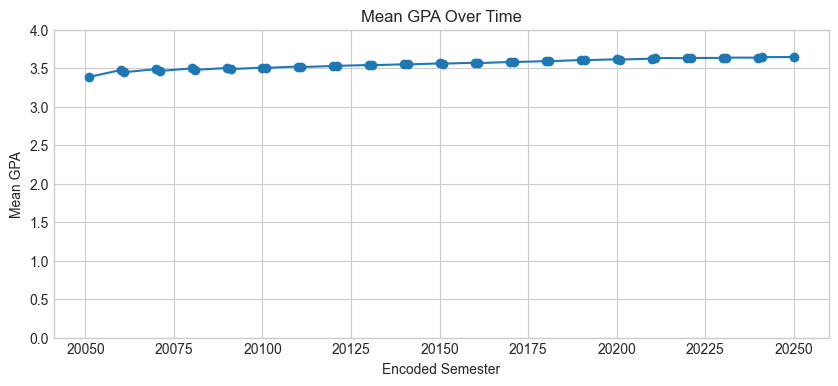

First semester mean: 3.385
Last semester mean:  3.644
P-value: 2.58e-105
Later semesters have higher mean GPA in this descriptive comparison -- keep semester as a temporal feature.


In [8]:
# encode semester as sortable int:
# year * 10 + (1 if Fall, 0 if Spring)

df['semesterEncoded'] = (
    df['year'] * 10
    + (df['semester'] == 'Fall').astype(int)
)

df = df.sort_values(['id', 'semesterEncoded'])

# plot mean GPA per semester to visualize the trend
semesterMeans = df.groupby('semesterEncoded')['gpa'].mean()

plt.figure(figsize=(10, 4))

plt.plot(
    semesterMeans.index,
    semesterMeans.values,
    marker='o'
)

plt.xlabel('Encoded Semester')
plt.ylabel('Mean GPA')
plt.ylim(0, 4)
plt.title('Mean GPA Over Time')
plt.grid(True)

plt.show()

# confirm trend with t-test: first vs last semester
firstSem = df[df['semesterEncoded'] == semesterMeans.index[0]]['gpa']
lastSem = df[df['semesterEncoded'] == semesterMeans.index[-1]]['gpa']

_, pValue = ttest_ind(firstSem, lastSem)

print(f"First semester mean: {firstSem.mean():.3f}")
print(f"Last semester mean:  {lastSem.mean():.3f}")
print(f"P-value: {pValue:.2e}")

print("Later semesters have higher mean GPA in this descriptive comparison -- keep semester as a temporal feature.")

The upward trend is strong, and the first-vs-last semester comparison suggests later semesters have higher GPAs. Because repeated semesters from the same student are not independent, treat the p-value as descriptive rather than exact. The modeling takeaway still stands: semester timing is a useful feature, and the train/test split needs to stay temporal to avoid leakage.

### Geographic Clustering

Raw latitude and longitude don't work great as direct model inputs since a 0.01 degree difference doesn't have a consistent meaning. Instead, we use K-Means clustering to group students into geographic regions based on where they live. K-Means finds k cluster centers that minimize the total distance from each point to its nearest center. We then one-hot encode the cluster labels so the model can use them.

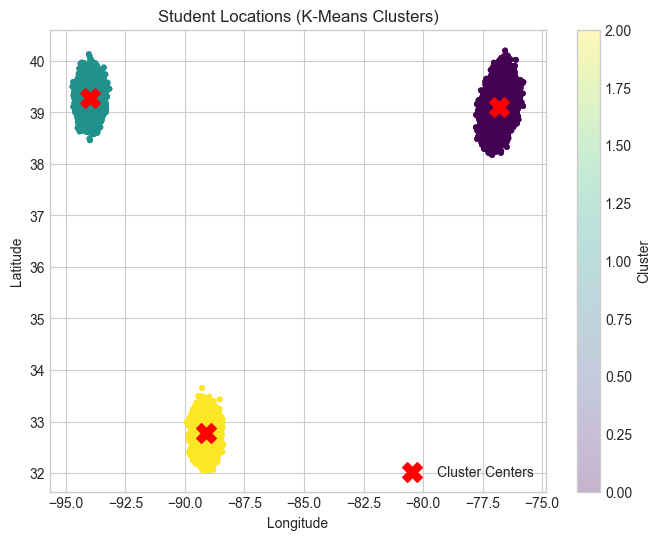

School cluster: 0 (center: [ 39.10386021 -76.81382233])
Region: Maryland, between DC and Baltimore


In [9]:
# cluster students by home coordinates (lat, lon)
coords = df[['lat', 'lon']]

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df['geoCluster'] = kmeans.fit_predict(coords)

clusterCenters = kmeans.cluster_centers_

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    df['lon'],
    df['lat'],
    c=df['geoCluster'],
    cmap='viridis',
    alpha=0.3,
    s=10
)

plt.scatter(
    clusterCenters[:, 1],
    clusterCenters[:, 0],
    color='red',
    marker='X',
    s=200,
    label='Cluster Centers'
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Student Locations (K-Means Clusters)')
plt.legend()
plt.colorbar(scatter, label='Cluster')
plt.show()

# highest-count cluster = most students live near campus
clusterCounts = pd.Series(df['geoCluster']).value_counts()

schoolCluster = clusterCounts.idxmax()

print(
    f"School cluster: {schoolCluster} "
    f"(center: {clusterCenters[schoolCluster]})"
)

print("Region: Maryland, between DC and Baltimore")

Three clear geographic clusters emerge. The largest one (most students) is near campus. The other two represent students commuting from farther away. These cluster labels replace raw coordinates as features.

### Missing Data & Outliers

Before feature engineering, we need to check for data quality issues: null values that would crash the model, and outliers that could skew predictions (like someone supposedly studying 10,000 hours per week).

In [10]:
# check for nulls
missingData = df.isnull().sum()

print("Columns with missing values:")
print(missingData[missingData > 0])

# check for impossible study hours (can't study > 24 hrs/day)
print(
    f"\navg_hours_studied range: "
    f"[{df['avg_hours_studied'].min()}, "
    f"{df['avg_hours_studied'].max()}]"
)

print(
    f"Values > 24 (impossible): "
    f"{(df['avg_hours_studied'] > 24).sum()}"
)

Columns with missing values:
tutoring    41945
dtype: int64

avg_hours_studied range: [0, 10000]
Values > 24 (impossible): 88


Two issues to fix: (1) about 42k missing tutoring values, and (2) 88 impossible study hour values above 24. We'll forward/backward fill the tutoring gaps from each student's other semester records since tutoring status tends to be stable. For study hours, we'll replace the impossible values (>24) with Q3 (the 75th percentile) as a realistic substitute.

## 3. Feature Engineering

### Outlier Capping

We cap extreme values rather than removing them since we don't want to lose entire rows over a single bad data point. GPA gets capped at 4.0 (max possible). For study hours, anything above 24 hrs/day is physically impossible and clearly a data entry error. We replace those values with Q3 (the 75th percentile) as a reasonable "high but realistic" substitute.

In [11]:
# cap GPA at 4.0 -- values above are data errors
df.loc[df['gpa'] > 4.0, 'gpa'] = 4.0

# cap study hours -- anything > 24 is impossible, replace with Q3
q3Hours = df['avg_hours_studied'].quantile(0.75)
df.loc[df['avg_hours_studied'] > 24, 'avg_hours_studied'] = q3Hours

print(f"GPA range after capping: [{df['gpa'].min():.2f}, {df['gpa'].max():.2f}]")
print(f"Study hours range after capping: [{df['avg_hours_studied'].min()}, {df['avg_hours_studied'].max()}]")
print(f"Q3 used for study hours cap: {q3Hours}")

GPA range after capping: [0.00, 4.00]
Study hours range after capping: [0, 11]
Q3 used for study hours cap: 5.0


### Fill Missing Tutoring

About 5% of rows are missing tutoring status. Since a student's tutoring status is relatively stable across semesters, we fill gaps by looking at the same student's other records. Forward fill first (carry previous value forward), then backward fill for students whose first record is missing.

This is also a good place to normalize a source-data typo: the raw dataset uses `Sophmore`, and we convert that to `Sophomore` before one-hot encoding so the feature names stay clean and consistent.

In [12]:
# fill missing tutoring from same student's other semesters
df['tutoring'] = df.groupby('id')['tutoring'].ffill().bfill()

# normalize source-data typo before one-hot encoding
df['student_year'] = df['student_year'].replace({'Sophmore': 'Sophomore'})

print(f"Missing tutoring after fill: {df['tutoring'].isnull().sum()}")
print(f"Student year values: {sorted(df['student_year'].unique())}")

Missing tutoring after fill: 0
Student year values: ['Freshman', 'Junior', 'Senior', 'Sophomore']


### Lag Feature (Previous Semester GPA)

This is the most important feature we're adding. For each student-semester row, we grab the student's GPA from their previous semester. A student's recent performance is the strongest predictor of their next GPA. We group by student ID, sort by time, and shift GPA down by 1 within each group. The first semester per student will be NaN (no history), so we drop those rows since we can't make a meaningful prediction without any prior data.

In [13]:
# sort by student and time so shift works correctly
df = df.sort_values(['id', 'semesterEncoded'])

# create lag feature -- each row gets the student's GPA from previous semester
df['prevGpa'] = df.groupby('id')['gpa'].shift(1)

print(f"Rows before dropping NaN lag: {len(df)}")

df = df.dropna(subset=['prevGpa'])

print(f"Rows after dropping NaN lag: {len(df)}")
print(f"Dropped: {850000 - len(df)} rows (first semester per student, no prior GPA available)")

# verify it worked -- show one student's progression
sampleStudent = df['id'].iloc[0]
print(f"\nSample student {sampleStudent}:")
print(df[df['id'] == sampleStudent][['semesterEncoded', 'gpa', 'prevGpa']].head())

Rows before dropping NaN lag: 850000
Rows after dropping NaN lag: 765000
Dropped: 85000 rows (first semester per student, no prior GPA available)

Sample student 13251:
   semesterEncoded   gpa  prevGpa
1            20080  3.65     3.64
2            20081  4.00     3.65
3            20090  4.00     4.00
4            20091  3.30     4.00
5            20100  4.00     3.30


### One-Hot Encoding

Categorical variables (major, tutoring, student_year, geoCluster) need to be converted to numbers for the model. One-hot encoding creates a binary column for each category, like major_CS = 1 if CS, 0 otherwise.

We use drop_first=True to avoid the "dummy variable trap." If you have 5 majors and create 5 binary columns, knowing 4 of them automatically tells you the 5th (they must sum to 1). That redundancy can confuse the model, so we drop one category and let it be the implicit baseline.

In [14]:
# one-hot encode categoricals
df = pd.get_dummies(df, columns=['major', 'tutoring', 'student_year', 'geoCluster'], drop_first=True)

# convert geoCluster dummies to int (get_dummies makes them bool)
geoCols = [col for col in df.columns if col.startswith('geoCluster_')]
df[geoCols] = df[geoCols].astype(int)

print(f"Columns after encoding: {df.shape[1]}")
print(f"New dummy columns: {[col for col in df.columns if '_' in col and col not in ['avg_hours_studied', 'parents_income', 'student_age']]}")

Columns after encoding: 23
New dummy columns: ['major_Engineering', 'major_English', 'major_Math', 'major_Physics', 'tutoring_Yes', 'student_year_Junior', 'student_year_Senior', 'student_year_Sophomore', 'geoCluster_1', 'geoCluster_2']


### Standardization

Numeric features have very different scales. parents_income is in tens of thousands, credits is 9-18, study hours is single digits.

Tree-based models do not require standardization, but if we keep it for interpretability and for the inference helper, we should fit the means/stds on the training set only. Doing it before the split would leak information from the future test period into training.

In [15]:
# keep track of which numeric columns we want to standardize later
# important: fit means/stds on the training set only after the temporal split
colsToStandardize = ['avg_hours_studied', 'parents_income', 'credits', 'semesterEncoded']
standardizeParams = {}

print("Standardization will be fit on xTrain only after the temporal split.")
print(f"Columns to standardize later: {colsToStandardize}")

Standardization will be fit on xTrain only after the temporal split.
Columns to standardize later: ['avg_hours_studied', 'parents_income', 'credits', 'semesterEncoded']


### Final Feature Set

Selecting the columns that go into the model. We drop identifiers (id), raw categoricals (already encoded), coordinates (replaced by cluster labels), and the target (gpa). The prevGPA lag feature stays as-is since it's already on the 0-4 scale.

In [16]:
# columns to exclude from features
dropCols = ['Unnamed: 0', 'id', 'gpa', 'lat', 'lon', 'semester', 'year', 'student_age']
featureCols = [col for col in df.columns if col not in dropCols]

X = df[featureCols]
y = df['gpa']

print(f"Feature matrix: {X.shape}")
print(f"Target: {y.shape}")
print(f"\nFeatures ({len(featureCols)}):")
print(featureCols)

Feature matrix: (765000, 15)
Target: (765000,)

Features (15):
['avg_hours_studied', 'parents_income', 'credits', 'semesterEncoded', 'prevGpa', 'major_Engineering', 'major_English', 'major_Math', 'major_Physics', 'tutoring_Yes', 'student_year_Junior', 'student_year_Senior', 'student_year_Sophomore', 'geoCluster_1', 'geoCluster_2']


## 4. Modeling

### Temporal Train/Test Split

Instead of randomly splitting rows, we split by time. Train on earlier semesters, test on later ones. This prevents data leakage: in a random split, the model could train on a student's senior year and test on their freshman year, which is backwards. A temporal split simulates how the model would actually be used in production, predicting future GPA based only on past data.

We also sort the rows globally by semester before modeling so later time-aware cross-validation uses the correct chronological order.

In [17]:
# sort globally by time so every later split/cv step respects chronology
sortIdx = df['semesterEncoded'].sort_values().index
dfModel = df.loc[sortIdx].reset_index(drop=True)
X = X.loc[sortIdx].reset_index(drop=True)
y = y.loc[sortIdx].reset_index(drop=True)

# split at the 70th percentile of the raw semester timeline
trainMask = dfModel['semesterEncoded'] <= dfModel['semesterEncoded'].quantile(0.7)
testMask = ~trainMask

xTrain, xTest = X[trainMask].copy(), X[testMask].copy()
yTrain, yTest = y[trainMask].copy(), y[testMask].copy()

# fit standardization on train only, then transform both sets
for col in colsToStandardize:
    mean = xTrain[col].mean()
    std = xTrain[col].std()
    standardizeParams[col] = {'mean': mean, 'std': std}
    xTrain[col] = (xTrain[col] - mean) / std
    xTest[col] = (xTest[col] - mean) / std

print(f"Train set: {xTrain.shape[0]} rows ({trainMask.sum() / len(dfModel) * 100:.1f}%)")
print(f"Test set:  {xTest.shape[0]} rows ({testMask.sum() / len(dfModel) * 100:.1f}%)")
print("Split logic: train on earlier ~70% of semesters, test on latest ~30%")
print("Standardization fit on xTrain only to avoid leakage.")

Train set: 536791 rows (70.2%)
Test set:  228209 rows (29.8%)
Split logic: train on earlier ~70% of semesters, test on latest ~30%
Standardization fit on xTrain only to avoid leakage.


### Baseline Models

Before tuning XGBoost, we train a Decision Tree and Random Forest as baselines. This gives us a reference point. If XGBoost doesn't beat these, the added complexity isn't worth it. We use R2 (coefficient of determination) as the metric: 1.0 means perfect predictions, 0.0 means no better than just predicting the mean every time.

In [18]:
# Decision Tree baseline
dtModel = DecisionTreeRegressor(random_state=42)
dtModel.fit(xTrain, yTrain)

dtPred = dtModel.predict(xTest)
dtR2 = r2_score(yTest, dtPred)
dtMse = mean_squared_error(yTest, dtPred)
print(f"Decision Tree -- R2: {dtR2:.4f}, MSE: {dtMse:.4f}")

# Random Forest baseline
rfModel = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rfModel.fit(xTrain, yTrain)

rfPred = rfModel.predict(xTest)
rfR2 = r2_score(yTest, rfPred)
rfMse = mean_squared_error(yTest, rfPred)
print(f"Random Forest -- R2: {rfR2:.4f}, MSE: {rfMse:.4f}")

Decision Tree -- R2: 0.7543, MSE: 0.0757
Random Forest -- R2: 0.8680, MSE: 0.0407


### XGBoost + Hyperparameter Tuning

XGBoost (Extreme Gradient Boosting) builds trees sequentially where each new tree focuses on correcting the mistakes of the previous ones.

RandomizedSearchCV randomly samples hyperparameter combinations from a search space and evaluates each with cross-validation. Instead of trying every possible combination (which could be thousands), it picks 20 random ones and finds the best. Way more efficient.

Because this is time-ordered data, we use `TimeSeriesSplit` rather than ordinary random K-folds so validation always happens on later data than training.

Key hyperparameters:

- `max_depth`: how deep each tree grows
- `learning_rate`: how much each tree contributes
- `n_estimators`: total number of trees
- `subsample`: fraction of rows each tree sees
- `colsample_bytree`: fraction of features each tree sees

In [19]:
# define hyperparameter search space
paramDist = {
    'max_depth': [3, 4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300, 500],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
}

# RandomizedSearchCV: try 20 random combinations, 3-fold time-series CV each
xgbBase = XGBRegressor(random_state=42, n_jobs=-1)
tscvTune = TimeSeriesSplit(n_splits=3)
randomSearch = RandomizedSearchCV(
    xgbBase,
    param_distributions=paramDist,
    n_iter=20,  # number of random combos to try
    cv=tscvTune,
    scoring='r2',
    random_state=42,
    verbose=1,
)

randomSearch.fit(xTrain, yTrain)

print(f"\nBest parameters: {randomSearch.best_params_}")
print(f"Best CV R2: {randomSearch.best_score_:.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best parameters: {'subsample': 0.7, 'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
Best CV R2: 0.9003


### Evaluate Tuned XGBoost on Test Set

Now we take the best model from the search and evaluate it on the held-out test set (the later semesters the model never saw during training). This is the final honest performance estimate.

In [20]:
# best model from search
xgbModel = randomSearch.best_estimator_

# predict on test set
xgbPred = xgbModel.predict(xTest)
xgbR2 = r2_score(yTest, xgbPred)
xgbMse = mean_squared_error(yTest, xgbPred)

print(f"XGBoost (tuned) -- R2: {xgbR2:.4f}, MSE: {xgbMse:.4f}")

print("Comparison:")
print(f"  Decision Tree  -- R2: {dtR2:.4f}, MSE: {dtMse:.4f}")
print(f"  Random Forest  -- R2: {rfR2:.4f}, MSE: {rfMse:.4f}")
print(f"  XGBoost (tuned) -- R2: {xgbR2:.4f}, MSE: {xgbMse:.4f}")

XGBoost (tuned) -- R2: 0.8777, MSE: 0.0377
Comparison:
  Decision Tree  -- R2: 0.7543, MSE: 0.0757
  Random Forest  -- R2: 0.8680, MSE: 0.0407
  XGBoost (tuned) -- R2: 0.8777, MSE: 0.0377


### 5-Fold Cross-Validation

A single train/test split can get lucky or unlucky depending on which rows fall where. Cross-validation gives a more stable estimate. For time-ordered data, that means a rolling evaluation where each split trains on earlier rows and validates on later rows.

The result is a mean plus/minus std (like R2 = 0.91 +/- 0.001). The mean tells us expected performance, the std tells us stability. A tight std means the model performs consistently regardless of which data it trains on.

In [21]:
# 5-fold rolling time-series CV on training set using the best XGBoost params
cvScores = cross_val_score(xgbModel, xTrain, yTrain, cv=TimeSeriesSplit(n_splits=5), scoring='r2', n_jobs=-1)

print(f"5-Fold CV R2 scores: {cvScores}")
print(f"Mean R2: {cvScores.mean():.4f} +/- {cvScores.std():.4f}")

5-Fold CV R2 scores: [0.90805847 0.90660802 0.90420832 0.90325007 0.90011874]
Mean R2: 0.9044 +/- 0.0028


### Validation Curve

A validation curve shows how model performance changes as we vary a single hyperparameter (here, max_depth). We plot both training and validation scores:

- If both are low, the model is underfitting (too simple)
- If training is high but validation is low, it's overfitting (memorized training data)
- The sweet spot is where validation score peaks

The gap between the two lines is the "generalization gap." A large gap means the model is overfitting to training data and won't perform as well on new data.

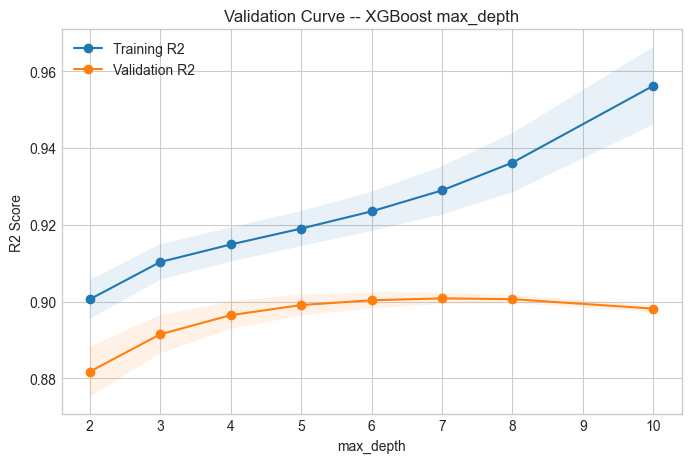

Best max_depth from search: 6


In [22]:
from sklearn.model_selection import validation_curve

# vary max_depth while keeping other params at best values
bestParams = randomSearch.best_params_.copy()
depthRange = [2, 3, 4, 5, 6, 7, 8, 10]

trainScores, valScores = validation_curve(
    XGBRegressor(
        learning_rate=bestParams['learning_rate'],
        n_estimators=bestParams['n_estimators'],
        subsample=bestParams['subsample'],
        colsample_bytree=bestParams['colsample_bytree'],
        random_state=42,
        n_jobs=-1,
    ),
    xTrain,
    yTrain,
    param_name='max_depth',
    param_range=depthRange,
    cv=TimeSeriesSplit(n_splits=3),
    scoring='r2',
    n_jobs=-1,
)

# plot
plt.figure(figsize=(8, 5))
plt.plot(depthRange, trainScores.mean(axis=1), 'o-', label='Training R2')
plt.plot(depthRange, valScores.mean(axis=1), 'o-', label='Validation R2')
plt.fill_between(depthRange, trainScores.mean(axis=1) - trainScores.std(axis=1), trainScores.mean(axis=1) + trainScores.std(axis=1), alpha=0.1)
plt.fill_between(depthRange, valScores.mean(axis=1) - valScores.std(axis=1), valScores.mean(axis=1) + valScores.std(axis=1), alpha=0.1)
plt.xlabel('max_depth')
plt.ylabel('R2 Score')
plt.title('Validation Curve -- XGBoost max_depth')
plt.legend()
plt.grid(True)
plt.show()

print(f"Best max_depth from search: {bestParams['max_depth']}")

## 5. Evaluation & Diagnostics

### Residual Analysis

R2 and MSE give you one number summarizing overall performance. Residual analysis shows where and how the model fails. A residual is just actual minus predicted, so how far off the model was for each prediction.

Two diagnostic plots:

- Predicted vs Actual scatter -- perfect model means all points land on the 45-degree diagonal. If points curve away in certain regions, the model has systematic blind spots there.
- Residual histogram -- should be centered at 0 and roughly symmetric. If it's skewed left, the model tends to over-predict. Skewed right means it under-predicts.

A mean residual near 0 means no overall bias. The std of residuals tells you the typical error magnitude.

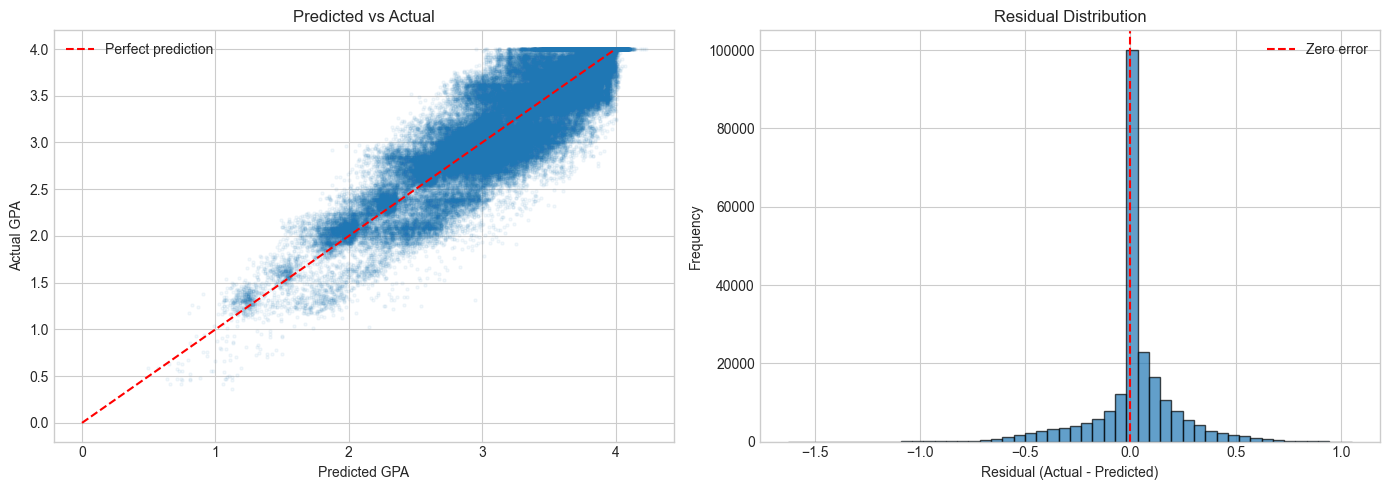

Residual stats:
  Mean: 0.0172 (near 0 is ideal; positive means slight underprediction)
  Std:  0.1933
  Skew: -0.2092


In [23]:
residuals = yTest.values - xgbPred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# predicted vs actual
axes[0].scatter(xgbPred, yTest, alpha=0.05, s=5)
axes[0].plot([0, 4], [0, 4], 'r--', label='Perfect prediction')  # diagonal
axes[0].set_xlabel('Predicted GPA')
axes[0].set_ylabel('Actual GPA')
axes[0].set_title('Predicted vs Actual')
axes[0].legend()

# residual distribution
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', label='Zero error')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Residual stats:")
print(f"  Mean: {residuals.mean():.4f} (near 0 is ideal; positive means slight underprediction)")
print(f"  Std:  {residuals.std():.4f}")
print(f"  Skew: {pd.Series(residuals).skew():.4f}")

### SHAP Feature Importance

SHAP (SHapley Additive exPlanations) answers the question: "for this specific prediction, how much did each feature push it up or down?"

Unlike basic feature importance, which just ranks features globally, SHAP shows both how important a feature is and which direction it pushes predictions for individual data points.

The beeswarm plot:

- Each row is one feature, ranked by overall importance
- Each dot is one individual prediction from the test set
- X-axis shows how much that feature pushed the prediction up/right or down/left
- Color represents the feature's actual value: red = high, blue = low

So for example, if prevGpa dots are red and pushed right, it means "when previous GPA is high, the model predicts higher future GPA." Makes intuitive sense.

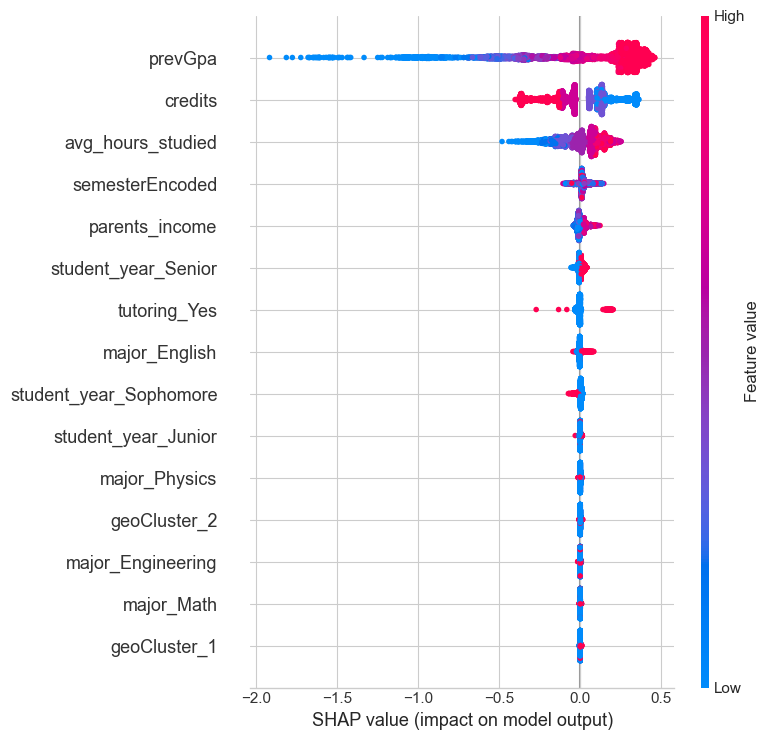

In [24]:
# SHAP values -- use a sample for speed (full dataset would be slow)
sampleSize = 5000
xSample = xTest.sample(n=sampleSize, random_state=42)

# TreeExplainer is optimized for tree-based models
explainer = shap.TreeExplainer(xgbModel)
shapValues = explainer.shap_values(xSample)

# beeswarm plot -- shows feature importance + direction of effect
shap.summary_plot(shapValues, xSample, show=False)
plt.tight_layout()
plt.show()

### Model Comparison Summary

Final comparison of all three models on the test set (later semesters none of the models trained on).

In [25]:
# summary table
results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'XGBoost (tuned)'],
    'R2': [dtR2, rfR2, xgbR2],
    'MSE': [dtMse, rfMse, xgbMse],
    'RMSE': [dtMse**0.5, rfMse**0.5, xgbMse**0.5],
})

results = results.sort_values('R2', ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

          Model       R2      MSE     RMSE
XGBoost (tuned) 0.877702 0.037681 0.194116
  Random Forest 0.868034 0.040660 0.201643
  Decision Tree 0.754255 0.075716 0.275165


## 6. Inference

A function that takes raw student info and returns a predicted GPA. Handles all the preprocessing internally (train-fit standardization, encoding) so you can just plug in real values and see what comes out. Useful for demonstrating the model interactively.

In [26]:
def predictGpa(avgHoursStudied, parentsIncome, major, tutoring, credits, studentYear, prevGpa, semesterEncoded, geoCluster):
    """
    Predict GPA for a student given their features.

    Args:
        avgHoursStudied: hours studied per week (0-24)
        parentsIncome: household income in dollars
        major: one of 'CS', 'Engineering', 'English', 'Math', 'Physics'
        tutoring: 'Yes' or 'No'
        credits: credits this semester (9, 12, 15, or 18)
        studentYear: 'Freshman', 'Sophomore', 'Junior', or 'Senior'
        prevGpa: GPA from previous semester (0.0-4.0)
        semesterEncoded: year*10 + (1 if Fall, 0 if Spring), e.g. 20231
        geoCluster: 0, 1, or 2 (from K-Means clustering)

    Returns:
        Predicted GPA (float, clamped to 0.0-4.0)
    """

    # standardize numeric features using params saved during training
    stdHours = (avgHoursStudied - standardizeParams['avg_hours_studied']['mean']) / standardizeParams['avg_hours_studied']['std']
    stdIncome = (parentsIncome - standardizeParams['parents_income']['mean']) / standardizeParams['parents_income']['std']
    stdCredits = (credits - standardizeParams['credits']['mean']) / standardizeParams['credits']['std']
    stdSemester = (semesterEncoded - standardizeParams['semesterEncoded']['mean']) / standardizeParams['semesterEncoded']['std']

    # build feature dict matching training column order
    features = {col: 0 for col in featureCols}
    features.update({
        'avg_hours_studied': stdHours,
        'parents_income': stdIncome,
        'credits': stdCredits,
        'semesterEncoded': stdSemester,
        'prevGpa': prevGpa,
        'major_Engineering': 1 if major == 'Engineering' else 0,
        'major_English': 1 if major == 'English' else 0,
        'major_Math': 1 if major == 'Math' else 0,
        'major_Physics': 1 if major == 'Physics' else 0,
        'tutoring_Yes': 1 if tutoring == 'Yes' else 0,
        'student_year_Junior': 1 if studentYear == 'Junior' else 0,
        'student_year_Senior': 1 if studentYear == 'Senior' else 0,
        'geoCluster_1': 1 if geoCluster == 1 else 0,
        'geoCluster_2': 1 if geoCluster == 2 else 0,
    })

    features['student_year_Sophomore'] = 1 if studentYear == 'Sophomore' else 0

    # create dataframe with correct column order
    inputDf = pd.DataFrame([features])[featureCols]
    prediction = xgbModel.predict(inputDf)[0]

    # clamp to valid GPA range
    prediction = max(0.0, min(4.0, float(prediction)))
    return round(prediction, 3)


print("predictGpa() function ready.")

predictGpa() function ready.


### Example Predictions

Testing the function with different student profiles to make sure the model responds sensibly to changes in inputs.

In [27]:
# strong student -- high prev GPA, good study habits, high income
pred1 = predictGpa(
    avgHoursStudied=8,
    parentsIncome=120000,
    major='English',
    tutoring='No',
    credits=15,
    studentYear='Senior',
    prevGpa=3.8,
    semesterEncoded=20231,
    geoCluster=0,
)
print(f"Strong student (prevGpa=3.8, 8hrs study, English, Senior): {pred1}")

# struggling student -- low prev GPA, less study, tutored
pred2 = predictGpa(
    avgHoursStudied=2,
    parentsIncome=45000,
    major='Engineering',
    tutoring='Yes',
    credits=18,
    studentYear='Sophomore',
    prevGpa=2.3,
    semesterEncoded=20231,
    geoCluster=1,
)
print(f"Struggling student (prevGpa=2.3, 2hrs study, Engineering, tutored): {pred2}")

# average student
pred3 = predictGpa(
    avgHoursStudied=4,
    parentsIncome=80000,
    major='CS',
    tutoring='No',
    credits=12,
    studentYear='Junior',
    prevGpa=3.2,
    semesterEncoded=20231,
    geoCluster=0,
)
print(f"Average student (prevGpa=3.2, 4hrs study, CS, Junior): {pred3}")

Strong student (prevGpa=3.8, 8hrs study, English, Senior): 3.888
Struggling student (prevGpa=2.3, 2hrs study, Engineering, tutored): 2.443
Average student (prevGpa=3.2, 4hrs study, CS, Junior): 3.393
